In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("sales.xlsx").copy()
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
df.head()

,Order_ID,Date,Product,Region,Quantity,Revenue,Status
0,ORD-1078,2023-05-05,monitor,West,36,12758.40,completed
1,ORD-1065,2024-03-22,Headphones,North,3,329.93,Cancelled
2,ORD-1094,2024/99/01,laptop,South,42,47183.64,completed
3,ORD-1022,2023-11-11,Tablet,South,8,3879.80,Completed
4,ORD-1063,2023-04-22,phone,west,17,10858.58,pending


In [2]:
df['Product'] = df['Product'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.capitalize()
df['Status'] = df['Status'].str.strip().str.upper()
df['Order_ID'] = df['Order_ID'].str.strip()
df = df.drop_duplicates(subset=['Order_ID'])
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].dt.date
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].abs()
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.dropna(subset=['Quantity'])


In [3]:
df.head()

,Order_ID,Date,Product,Region,Quantity,Revenue,Status
0,ORD-1078,2023-05-05,Monitor,West,36.0,12758.40,COMPLETED
1,ORD-1065,2024-03-22,Headphones,North,3.0,329.93,CANCELLED
3,ORD-1022,2023-11-11,Tablet,South,8.0,3879.80,COMPLETED
4,ORD-1063,2023-04-22,Phone,West,17.0,10858.58,PENDING
5,ORD-1046,2023-04-13,Laptop,North,40.0,29010.50,CANCELLED


In [4]:
df['Order_Num'] = df['Order_ID'].str.extract('(\d+)').astype(int)
df = df.sort_values(by='Order_Num', ascending=True).reset_index(drop=True)
df = df.drop(columns=['Order_Num'])


In [5]:
df

,Order_ID,Date,Product,Region,Quantity,Revenue,Status
0,ORD-1000,2023-08-17,Laptop,North,18.0,15457.50,COMPLETED
1,ORD-1001,2024-03-08,Laptop,North,35.0,38039.05,COMPLETED
2,ORD-1002,2023-01-28,Laptop,West,33.0,25988.61,COMPLETED
3,ORD-1003,2023-10-12,Monitor,North,29.0,8599.89,COMPLETED
4,ORD-1004,2023-12-11,Tablet,North,10.0,4845.30,COMPLETED
...,...,...,...,...,...,...,...
186,ORD-1195,2023-08-09,Laptop,East,42.0,41000.38,PENDING
187,ORD-1196,2024-03-01,Phone,North,30.0,-5000.00,PENDING
188,ORD-1197,2023-06-06,Tablet,West,17.0,7746.83,NaN
189,ORD-1198,2023-04-09,Laptop,East,6.0,6161.99,COMPLETED


In [14]:
df = df.fillna(0)
df.to_excel("finished.xlsx",index=False)
df.head()

,Order_ID,Date,Product,Region,Quantity,Revenue,Status,Month
0,ORD-1000,2023-08-17,Laptop,North,18.0,15457.50,COMPLETED,2023-08
1,ORD-1001,2024-03-08,Laptop,North,35.0,38039.05,COMPLETED,2024-03
2,ORD-1002,2023-01-28,Laptop,West,33.0,25988.61,COMPLETED,2023-01
3,ORD-1003,2023-10-12,Monitor,North,29.0,8599.89,COMPLETED,2023-10
4,ORD-1004,2023-12-11,Tablet,North,10.0,4845.30,COMPLETED,2023-12


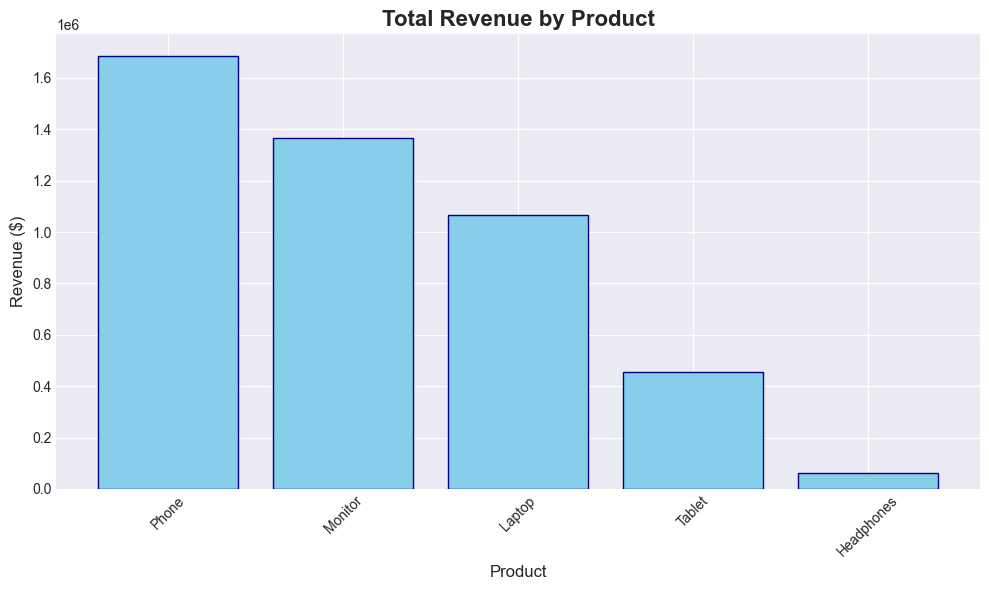

Top Product: Phone ($1,684,401.77)


In [7]:
#product revenues bar chart
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(product_revenue.index, product_revenue.values, color='skyblue', edgecolor='navy')
plt.title('Total Revenue by Product', fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Top Product: {product_revenue.index[0]} (${product_revenue.values[0]:,.2f})")

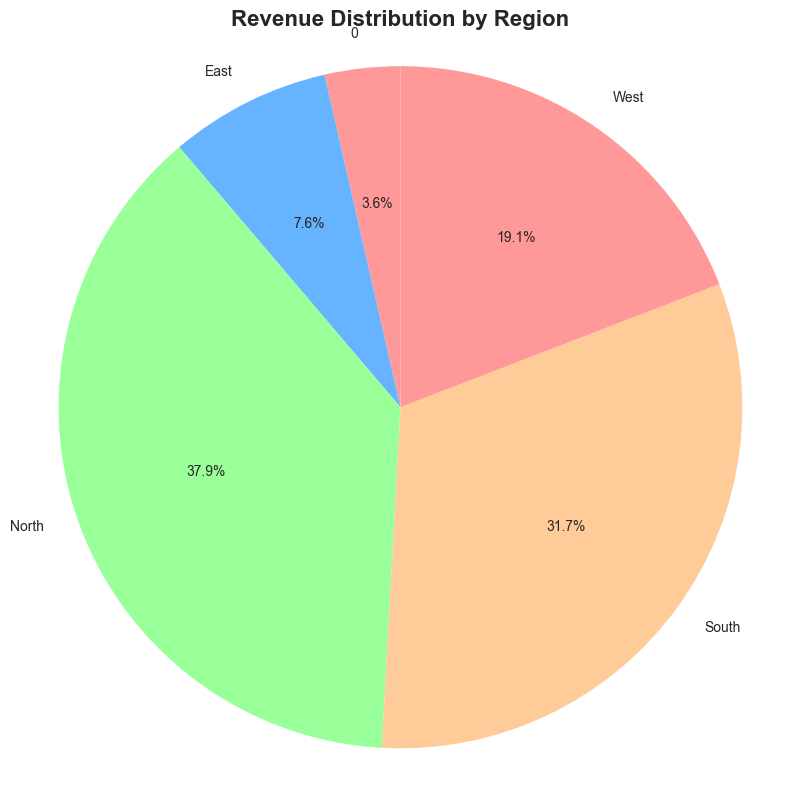

In [11]:
#region wise pie chart
region_revenue = df.groupby('Region')['Revenue'].sum()

plt.figure(figsize=(8, 8))
plt.pie(region_revenue.values, 
        labels=region_revenue.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Revenue Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.show()

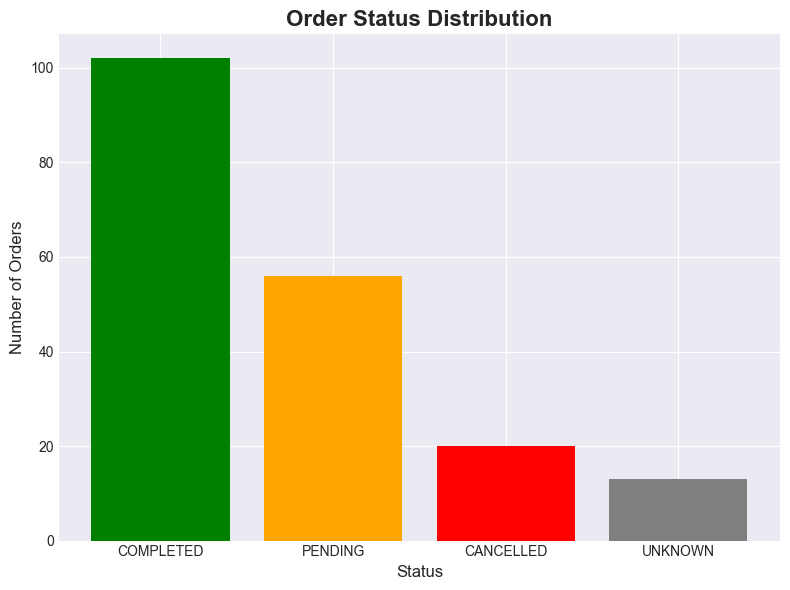

Completion Rate: 53.4%


In [13]:
#statuses barchart
df['Status'] = df['Status'].astype(str) 
df['Status'] = df['Status'].str.replace("0","UNKNOWN")
status_counts = df['Status'].value_counts()

plt.figure(figsize=(8, 6))
colors = {'COMPLETED': 'green', 'PENDING': 'orange', 'CANCELLED': 'red'}
plt.bar(status_counts.index, status_counts.values, 
        color=[colors.get(status, 'gray') for status in status_counts.index])
plt.title('Order Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Completion Rate: {(status_counts.get('COMPLETED', 0) / len(df) * 100):.1f}%")

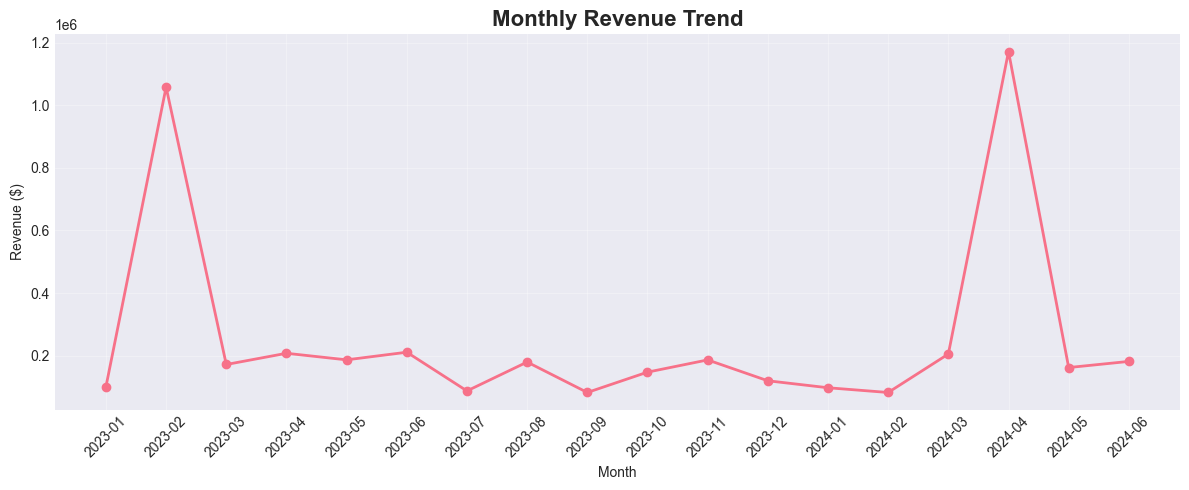

In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.to_period('M')
monthly_rev = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_rev['Month'] = monthly_rev['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_rev['Month'], monthly_rev['Revenue'], marker='o', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)T
plt.tight_layout()
plt.show()